# Chains in Langchain:

A chain in LangChain connects multiple components together (prompt → model → output) so you can build workflows instead of calling an LLM directly.

Input → Prompt → LLM → Output

In [ ]:
!pip install langchain_openai langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 28.8 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [ ]:
from langchain_openai import ChatOpenAI

In [ ]:
from langchain_core.prompts import ChatPromptTemplate

In [ ]:
from langchain_core.output_parsers import StrOutputParser

In [ ]:
from google.colab import userdata
api_key = userdata.get('OPENROUTER_SECRET')

In [ ]:
llm = ChatOpenAI(
    api_key=api_key,
    model="nvidia/nemotron-3-nano-omni-30b-a3b-reasoning:free",
    base_url="https://openrouter.ai/api/v1"
)

# 1. Simple Chain

A simple chain connects one prompt to one model.

In [ ]:
prompt = ChatPromptTemplate.from_template(
    "Explain {topic} in simple words"
)

chain = prompt | llm | StrOutputParser()

response = chain.invoke({
    "topic":"Machine Learning"
})

print(response)

Here's a simple explanation of **Machine Learning** in everyday words:

Imagine you're teaching a **child** to recognize cats.  
You show them *hundreds of pictures* of cats (with pointy ears, whiskers, etc.) and say, *"This is a cat."*  
After seeing enough examples, the child *starts to notice patterns* and can guess, *"That’s a cat!"* even for a new picture they’ve never seen.

**Machine Learning is exactly that—but for computers.**  
Instead of programming a computer with *every single rule* (e.g., "If it has pointy ears, it’s a cat"), you **show it lots of examples** (like pictures of cats and non-cats). The computer then **figures out the patterns by itself** and gets better the more examples it sees.

### Key points:
- ✅ **No hard rules**: You don’t tell it *how* to decide—just give it examples.
- ✅ **Gets better with practice**: More data = better predictions (like the child learning faster with more cat pictures).
- ✅ **Used everywhere**: Spam filters (learns from spam/non-spa

# 2. Sequential Chain

A sequential chain sends the output of one step into another step.

In [ ]:
summary_prompt = ChatPromptTemplate.from_template(
    "Write a short explanation about {topic}"
)

translation_prompt = ChatPromptTemplate.from_template(
    "Translate the following into Urdu:\n{text}"
)

# summary chain
summary_chain = summary_prompt | llm | StrOutputParser()

# Translation chain
translation_chain = translation_prompt | llm | StrOutputParser()


full_chain = (
    {"text": summary_chain}
    | translation_chain
)

response = full_chain.invoke({
    "topic":"Artificial Intelligence"
})

print(response)

کمپیوٹر سائنس کی ایک شاخ ہے جو اساتہام سے سرگرم کردہ نظام بناتا ہے جو عام طور پر انسانی هوش یادگار کام انجام دے سکتے ہیں۔ یہ کام میں سے شامل ہیں: ڈیٹا سے سیکھنا، پَٹینوں کی پہچان، زبان کی سمجھ بوجھ، فیصلہ کرنا، اور مسائل کا حل کرنا۔ AI اس کے لیے الگ الگ الگورتھم استعمال کرتا ہے—وہ قدم بہ قدم کی طریقے ہیں جو کمپیوٹر کو معلومات کا پروسیس کرنے، نئے ان پُٹس پر ایڈجسٹ کرنے اور وقت کے ساتھ بہتر کارکردگی حاصل کرنے کی اجازت دیتے ہیں۔ انسان کی سمجھ بوجھ، تفکر اور تخلیقی عناصر کو مدنظر رکھتے ہوئے، AI معمولی کام کو خودکار بناتا ہے، پیچیدہ تجزیے میں مدد کرتا ہے، اور مواد بھی تیار کر سکتا ہے، جبکہ اس کے قابلیت کو مسلسل تجربے کی مدد سے بہتر بناتا رہتا ہے۔


# 3. Conditional Chain

Conditional chains choose different paths based on conditions.

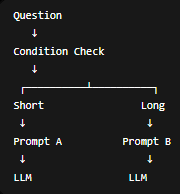

In [ ]:
from langchain_core.runnables import RunnableBranch

In [ ]:
short_prompt = ChatPromptTemplate.from_template(
    "Answer briefly: {question}"
)

long_prompt = ChatPromptTemplate.from_template(
    "Provide a detailed explanation: {question}"
)

chain = RunnableBranch(
    (
        lambda x: len(x["question"]) < 30,
        short_prompt | llm | StrOutputParser(),
    ),
    long_prompt | llm | StrOutputParser(),
)

response = chain.invoke({
    "question":"What is AI?"
})

print(response)

AI (Artificial Intelligence)is the field of computer science that creates systems capable of performing tasks that normally require human intelligence, such as learning, reasoning, perception, and decision‑making.


# 4. Parallel Chain

Parallel chains run multiple tasks simultaneously.

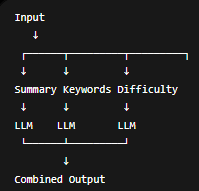

In [ ]:
from langchain_core.runnables import RunnableParallel

In [ ]:
# summary Template
summarytemplate = ChatPromptTemplate.from_template(
        "Summarize {topic}"
    )

# Summary chain
summary = (
    summarytemplate | llm | StrOutputParser()
)

# keyword Template
keywordtemplate = ChatPromptTemplate.from_template(
        "Extract keywords from {topic}"
    )

keywords = (keywordtemplate | llm | StrOutputParser())

# parallel chain
parallel_chain = RunnableParallel(
    summary=summary,
    keywords=keywords,
)

response = parallel_chain.invoke({
    "topic":"Deep Learning"
})

print(response['summary'])
print(response['keywords'])

**Deep Learning – A Concise Summary**

**What it is**  
Deep learning (DL) is a sub‑field of machine learning that models data using *artificial neural networks* with many stacked layers (hence “deep”). These networks automatically learn hierarchical representations of raw inputs, eliminating the need for manual feature engineering.

**Core Concepts**

| Concept | What it does | Key Points |
|---------|--------------|------------|
| **Artificial neuron** | Computes a weighted sum of inputs + bias, applies an activation function (e.g., ReLU, sigmoid). | The basic computational unit of a network. |
| **Layer** | A set of neurons that process the same type of transformation. | *Fully‑connected (dense)*, *convolutional*, *recurrent*, *transformer*, etc., each suited to particular data structures. |
| **Depth** | Number of layers between input and output. | More depth enables abstraction of increasingly complex features. |
| **Back‑propagation** | Efficient algorithm for computing gradients